## CIFAR-10 Nearest Neighbor Classifier

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision.datasets import CIFAR10

### Download(actually load) CIFAR-10

In [2]:
train_dataset = CIFAR10(
    root="../../datasets/raw",
    train=True,
    download=False
)

test_dataset = CIFAR10(
    root="../../datasets/raw",
    train=False,
    download=False
)

### High-Level Dataset Structure

In [3]:
print(len(train_dataset))
print(len(test_dataset))
classes = train_dataset.classes
print(classes)

50000
10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Visualize Dataset Structure

```
CIFAR-10
│
├── Training Set (50,000)
│   ├── airplane (5000)
│   ├── automobile (5000)
│   ├── bird (5000)
│   ├── ...
│
└── Test Set (10,000)
    ├── airplane (1000)
    ├── automobile (1000)
    ├── bird (1000)
    ├── ...
```

### Inspect One Sample Completely

In [4]:
image, label = train_dataset[0]

Type: <class 'PIL.Image.Image'>
Label ID: 6
Class: frog


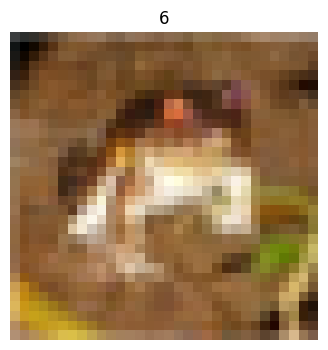

In [5]:
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title(label)
plt.axis('off')
plt.show

print('Type:', type(image))
print('Label ID:', label)
print('Class:', train_dataset.classes[label])

In [6]:
img_np = np.array(image)

print('Shape:', img_np.shape)
print('Dtype:', img_np.dtype)
print('Min:', img_np.min())
print('Max:', img_np.max())

Shape: (32, 32, 3)
Dtype: uint8
Min: 0
Max: 255


### Visualize One Image as Numbers

In [7]:
print(img_np)

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


### Visualize RGB Channels

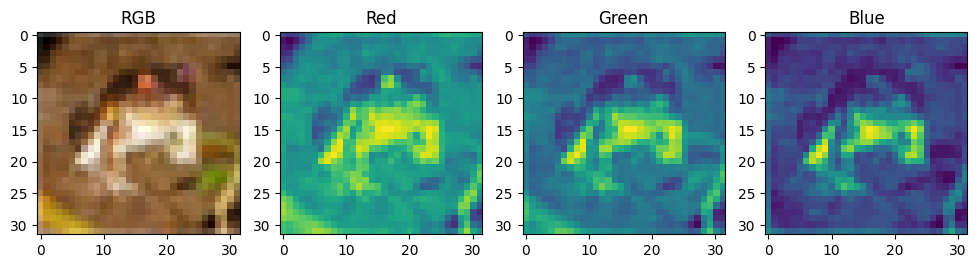

In [8]:
img_np = np.array(image)

fig, ax = plt.subplots(
    1,
    4,
    figsize=(12,4)
)

ax[0].imshow(img_np)
ax[0].set_title("RGB")

ax[1].imshow(img_np[:,:,0])
ax[1].set_title("Red")

ax[2].imshow(img_np[:,:,1])
ax[2].set_title("Green")

ax[3].imshow(img_np[:,:,2])
ax[3].set_title("Blue")

plt.show()

### Visualize Class Distribution

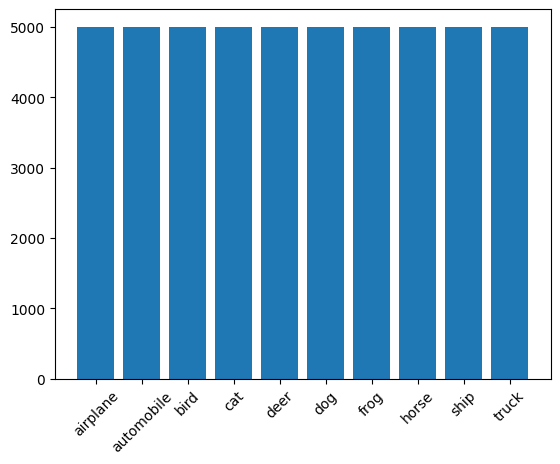

In [9]:
from collections import Counter

labels = [label for _, label in train_dataset]

counts = Counter(labels)

plt.bar(
    range(10),
    [counts[i] for i in range(10)]
)

plt.xticks(
    range(10),
    train_dataset.classes,
    rotation=45
)

plt.show()

### Show One Example From Each Class

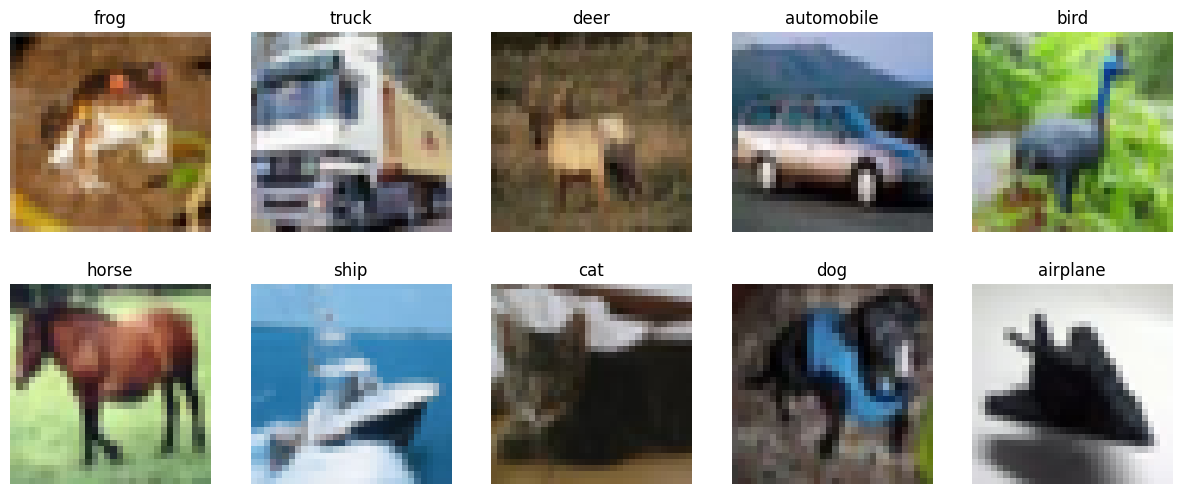

In [10]:
plt.figure(figsize=(15,6))

shown = set()

idx = 0

while len(shown) < 10:

    img, label = train_dataset[idx]

    if label not in shown:

        shown.add(label)

        plt.subplot(
            2,
            5,
            len(shown)
        )

        plt.imshow(img)

        plt.title(
            train_dataset.classes[label]
        )

        plt.axis("off")

    idx += 1

plt.show()

### Show 10 Random Images Per Class

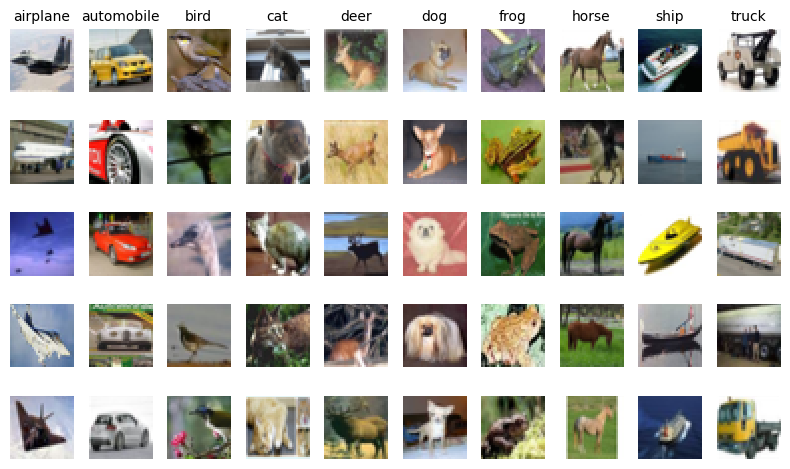

In [11]:
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Collect indices for each class
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(train_dataset):
    class_indices[label].append(idx)

fig, axes = plt.subplots(
    nrows=5,   # images per class
    ncols=10,   # classes
    figsize=(8, 5)
)

for label in range(10):

    # Class name at the top
    axes[0, label].set_title(
        train_dataset.classes[label],
        fontsize=10
    )

    # Randomly select 5 images from this class
    selected = random.sample(
        class_indices[label],
        5
    )

    for row, idx in enumerate(selected):

        img, _ = train_dataset[idx]

        ax = axes[row, label]

        ax.imshow(img)  # or img.permute(1,2,0) for PyTorch tensors
        ax.axis("off")

plt.tight_layout()
plt.show()

### Visualize Dataset Statistics

In [12]:
X_train = np.array(
    [np.array(img) for img, _ in train_dataset]
)

In [13]:
print("Mean:", X_train.mean())
print("Std :", X_train.std())

print("Min :", X_train.min())
print("Max :", X_train.max())

Mean: 120.70756512369792
Std : 64.15007589112135
Min : 0
Max : 255


### Visualize Pixel Distribution

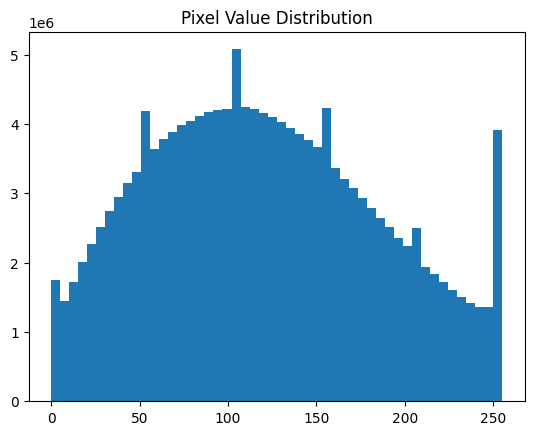

In [14]:
plt.hist(
    X_train.flatten(),
    bins=50
)

plt.title(
    "Pixel Value Distribution"
)

plt.show()

### Visualize What Flattening Does

In [15]:
img = np.array(train_dataset[0][0])
print(img.shape)

(32, 32, 3)


In [16]:
flat = img.reshape(-1)

print(flat.shape)

(3072,)
